In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
#include("../src/flexOPT.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

  Activating project at `~/Documents/Github/flexOPT`


devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]
→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


Main.GeoPoints

In [2]:
using .commonBatchs, UnPack, Symbolics

In [35]:
include("../src/compactSymbolicFunctions/compactFunctionsArray.jl")
include("../src/compactSymbolicFunctions/BsplineHelpers.jl")
include("../src/CompactSymbolicFunctions/TaylorExpansionHelpers.jl")

plotTaylorExpansions (generic function with 1 method)

# input parameters

for B-spline

In [4]:
orderBspline1D = 2
YorderBspline1D = 3
#the coordinate in Δy is (as usual) with the offset 1
μᶜs = [1,1.5,2.5,3] # ∈ R for variable, the nodes for interpolated Taylor expansions
μs = [1,1.5,2.5,3] # ∈ R for field, the nodes for interpolated Taylor expansions
nodesFromOne = [1,2,3] # ∈ Z like [1,2,3], an array of integers collect(1:1:N) (nothing else!!)
ν = [2] # this should be one point (for the moment)

1-element Vector{Int64}:
 2

for Taylor expansion

In [5]:
lᶜ_nᶜ_max = 4 # variable
l_n_max = 4 # field


4

for ill-posed inversion of Taylor expansion coefficients

In [6]:
Δ = 1.0 # Float64


1.0

In [7]:

paramsforWYYKKIntegral = (orderBspline1D=orderBspline1D, YorderBspline1D=YorderBspline1D, μᶜs=μᶜs, μs=μs, nodesFromOne=nodesFromOne, ν=ν, Δ=Δ, l_n_max=l_n_max, lᶜ_nᶜ_max=lᶜ_nᶜ_max)

(orderBspline1D = 2, YorderBspline1D = 3, μᶜs = [1.0, 1.5, 2.5, 3.0], μs = [1.0, 1.5, 2.5, 3.0], nodesFromOne = [1, 2, 3], ν = [2], Δ = 1.0, l_n_max = 4, lᶜ_nᶜ_max = 4)

# starting 'WYYKKIntegral1D(paramsforWYYKKIntegral)'

In [8]:
# Δ should be strictly Float64

    # orders: -1 -> indicator function, 0 -> box car, >=1 -> B-spline

    # this computes the analytical value of the 1D integral between B-spline fns and weighted Taylor kernels
    # \int dx Bspline Y_μᶜ Y_μ  K_{lᶜ-nᶜ}(y-y_μᶜ) K_{l-n}(y-y_μ)

    # unlike the previous integralBsplineTaylorKernels1D, it computes for a specific ν
    # Cˡη;μ are computed for a specific geometry, so even though the boundary condition reduces
    # the number of available points, each Taylor expansion for K_{l-n}(y-y_μ) should be Ok

    @unpack orderBspline1D, YorderBspline1D, μᶜs, μs, nodesFromOne, ν, Δ, l_n_max, lᶜ_nᶜ_max = paramsforWYYKKIntegral


(orderBspline1D = 2, YorderBspline1D = 3, μᶜs = [1.0, 1.5, 2.5, 3.0], μs = [1.0, 1.5, 2.5, 3.0], nodesFromOne = [1, 2, 3], ν = [2], Δ = 1.0, l_n_max = 4, lᶜ_nᶜ_max = 4)

# preparation of B-splines (all these things should be inside the package)

In [9]:


allNodes = unique(sort(vcat(
    Float64.(nodesFromOne),
    Float64.(ν),
    Float64.(μs),
    Float64.(μᶜs),
)))

to_indices(xs, master) = searchsortedfirst.(Ref(master), Float64.(xs))

idx_nodesFromOne = to_indices(nodesFromOne, allNodes)
idx_ν            = to_indices(ν, allNodes)
idx_μs           = to_indices(μs, allNodes)
idx_μᶜs          = to_indices(μᶜs, allNodes)



4-element Vector{Int64}:
 1
 2
 4
 5

In [10]:
# for B-spline

paramsBSν  = (maximumOrder=orderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_nodesFromOne, idx_selectedPoints = idx_ν)
paramsBSμᶜ = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μᶜs)
paramsBSμ  = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μs)
# idx_nodesNum : an ordinary consecutive integer increment from 1 (the numerical nodes with Δy)
# idx_refPoints_original : supporting nodes to construct the Bspline family
# idx_selectedPoints  : the node addresses that user needs to take, should be a subset of idx_refPoints_original


# for Taylor Expansions

paramsTEμᶜ = (maxL_MINUS_N=lᶜ_nᶜ_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μᶜs)
paramsTEμ  = (maxL_MINUS_N=l_n_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μs)




(maxL_MINUS_N = 4, allNodes = [1.0, 1.5, 2.0, 2.5, 3.0], idx_nodesNum = [1, 3, 5], idx_selectedPoints = [1, 2, 4, 5])

# computing $Y_\mu$, $Y_{\mu^\prime}$, $W_\nu$

In [11]:
Wν = constructBsplineFamily(paramsBSν);
Yμᶜ = constructBsplineFamily(paramsBSμᶜ);
Yμ = constructBsplineFamily(paramsBSμ);

In [12]:
Wν.b

CompactSymbolicFunctions{2, Array{Num, 4}}(5, 1, (3, 3), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[0; 0; … ; 1; 0;;; 0; 0; … ; 0; 0;;; 0; 0; … ; 0; 0;;;; (x - Δx) / Δx; (x - Δx) / Δx; … ; (-x + 3.0Δx) / Δx; 0;;; 1 / Δx; 1 / Δx; … ; -1.0 / Δx; 0;;; 0; 0; … ; 0; 0;;;; (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); … ; (-(x^2) + 6.0x*Δx - 8.0(Δx^2)) / (2.0(Δx^2)) + (-(x^2) + 4.0x*Δx - 3.0(Δx^2)) / (2.0(Δx^2)); 0;;; (2x - 2Δx) / (2.0(Δx^2)); (2x - 2Δx) / (2.0(Δx^2)); … ; (-8.0x + 20.0Δx) / (4.0(Δx^2)); 0;;; 2 / (2.0(Δx^2)); 2 / (2.0(Δx^2)); … ; -8.0 / (4.0(Δx^2)); 0])

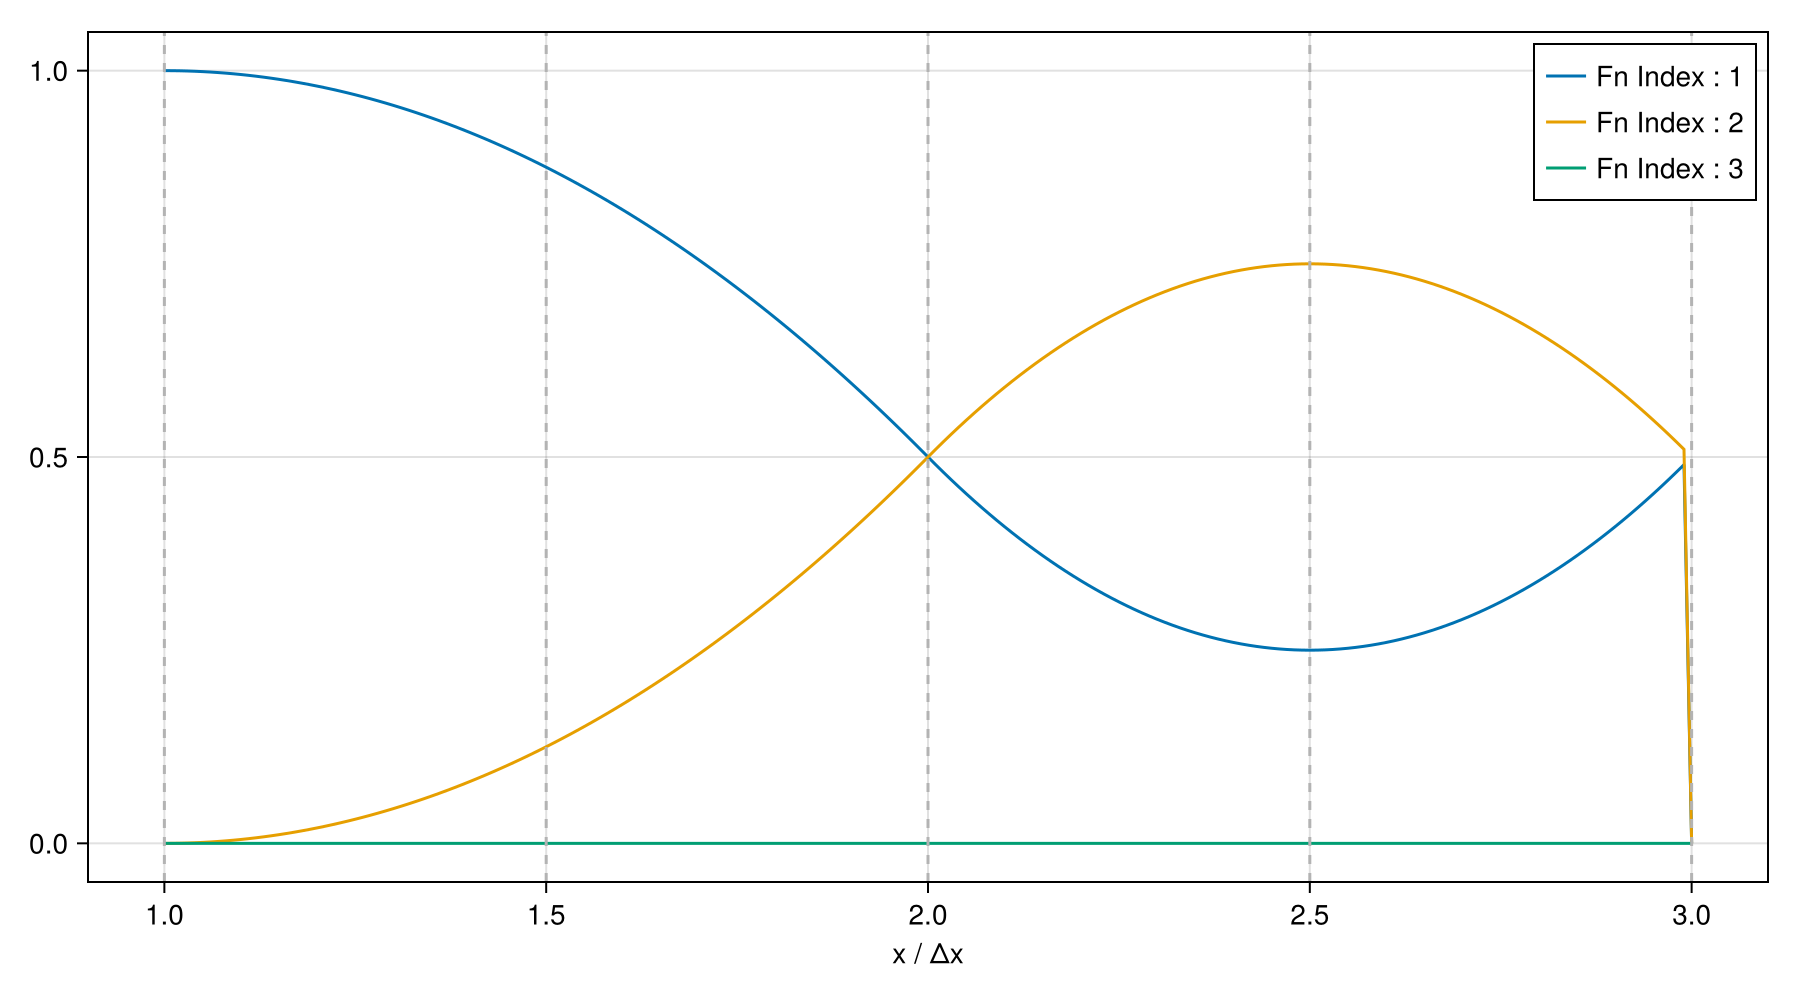

CairoMakie.Screen{IMAGE}


In [13]:

fig=plotBSpline(Wν.b_support; derivOrder=0,order=2, N=50)
display(fig)

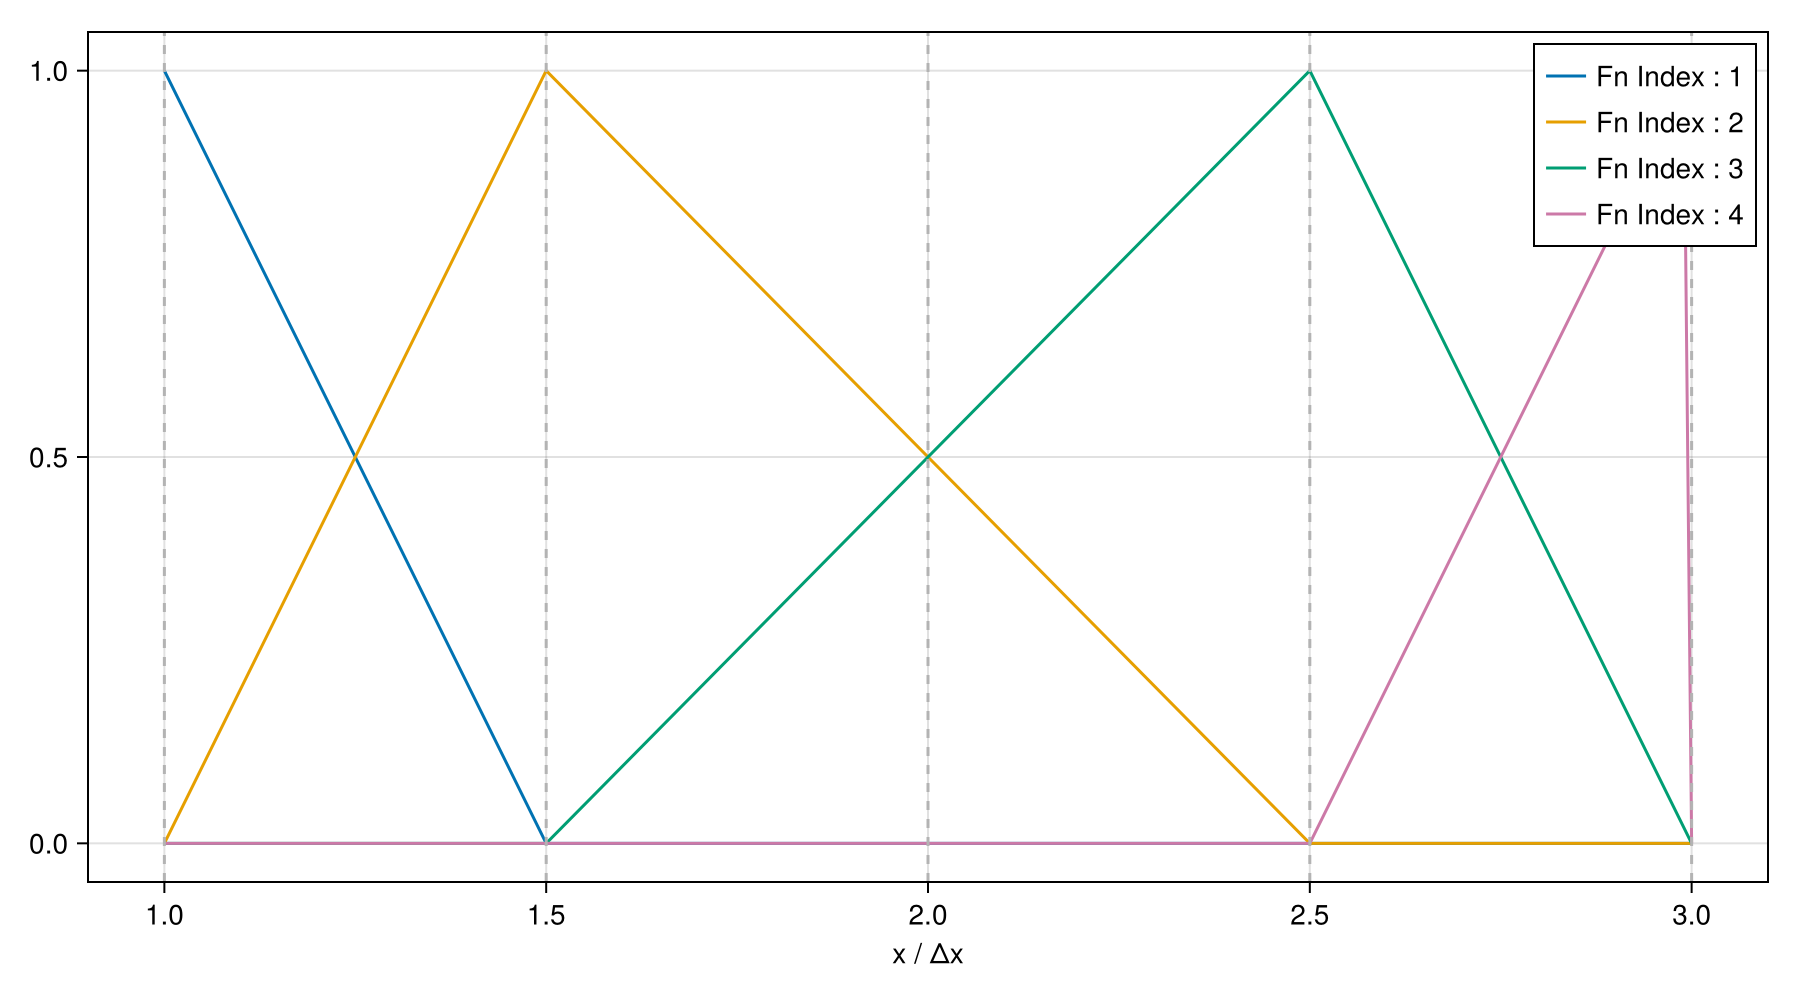

In [14]:
plotBSpline(Yμ.b; derivOrder=0, order=1, N=50)

# computing $K_\mu$, $K_{\mu^\prime}$

In [15]:
Kμᶜ=constructTaylorExpansions(paramsTEμᶜ) 
Kμ=constructTaylorExpansions(paramsTEμ) 

(k = CompactSymbolicFunctions{1, Array{Num, 3}}(5, 4, (5,), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0; … ; 1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0;;; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; … ; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx;;; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); … ; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2);;; 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 1.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 2.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666

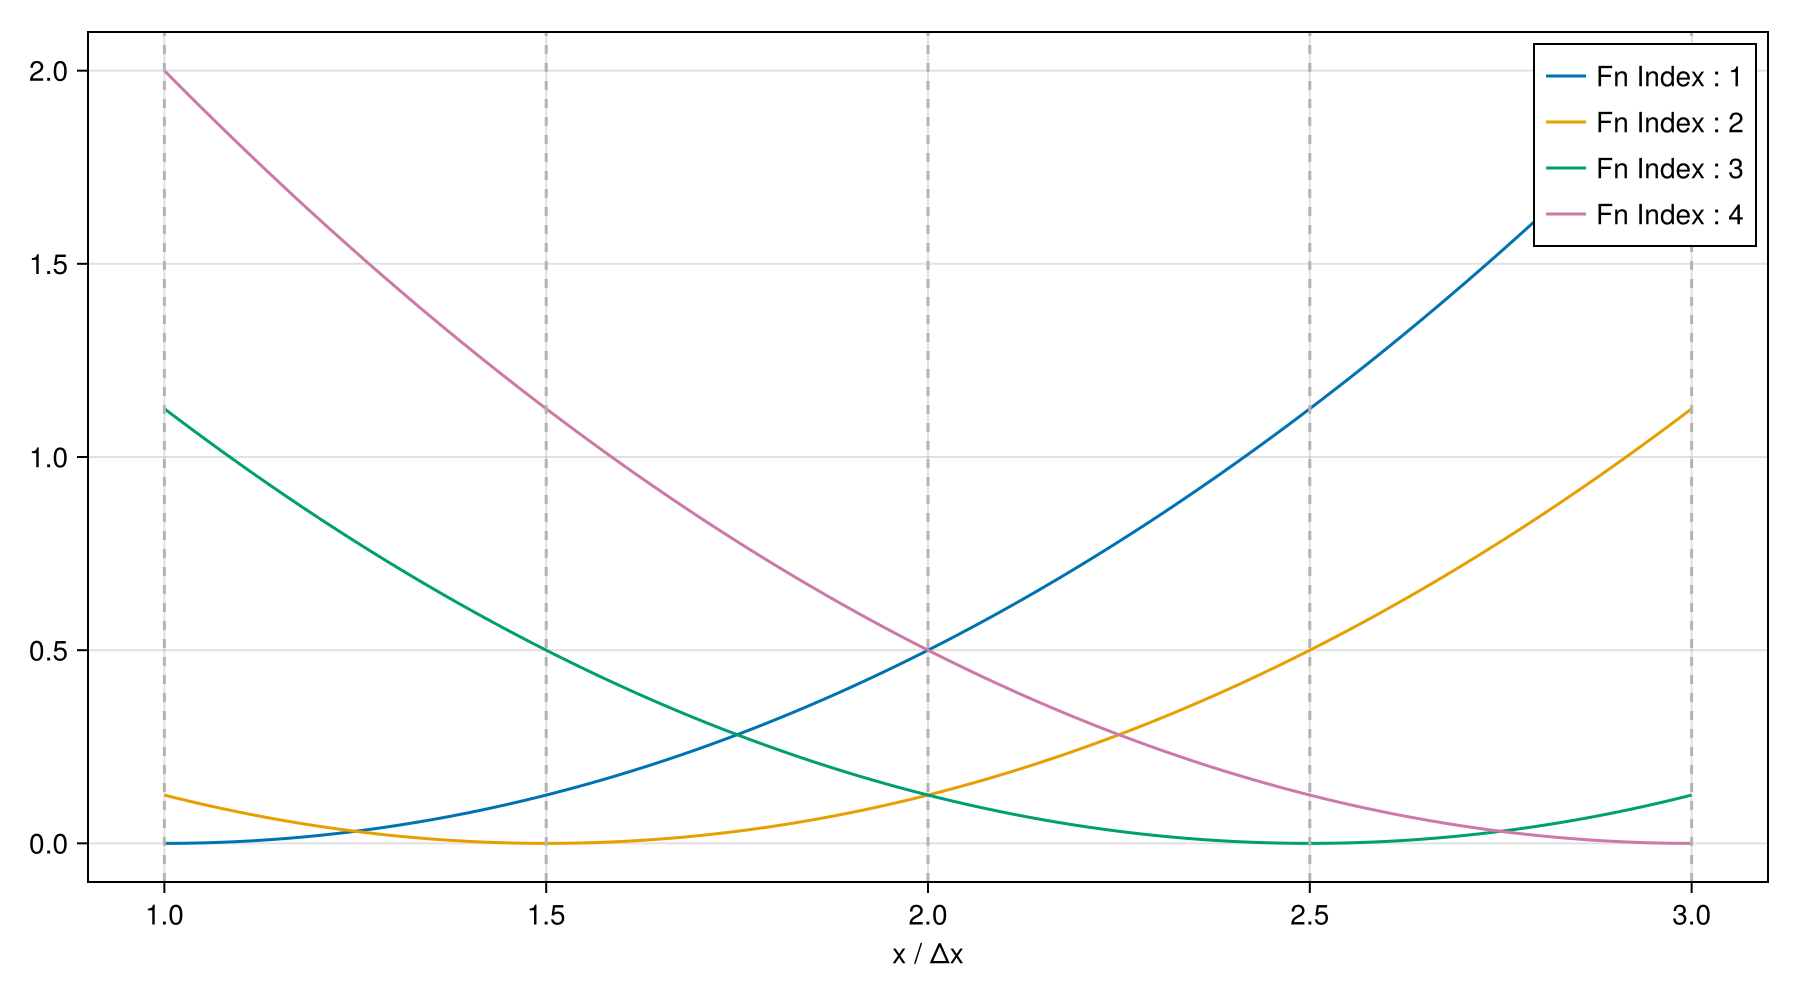

In [16]:
plotTaylorExpansions(Kμᶜ.k; l_n=2, N=50)

# constructing WYYKK functions

In [17]:
WYYKK=CompactSymbolicFunctions(Yμ.b.nodes,1;auxDims=(l_n_max+1, lᶜ_nᶜ_max+1, length(μs),length(μᶜs),),variables=Yμ.b.variables)
YorderSlot = YorderBspline1D + 1 
orderSlot = orderBspline1D + 1
derivSlot = 1 # no derivatives
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    WYYKK.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ] = mySimplify(Wν.b.data[:,1,derivSlot,orderSlot].*Yμᶜ.b.data[:,iμᶜ,derivSlot,YorderSlot].*Yμ.b.data[:,iμ,derivSlot,YorderSlot].*Kμᶜ.k.data[:,iμᶜ,lᶜ_nᶜ_slot].*Kμ.k.data[:,iμ,l_n_slot])
end

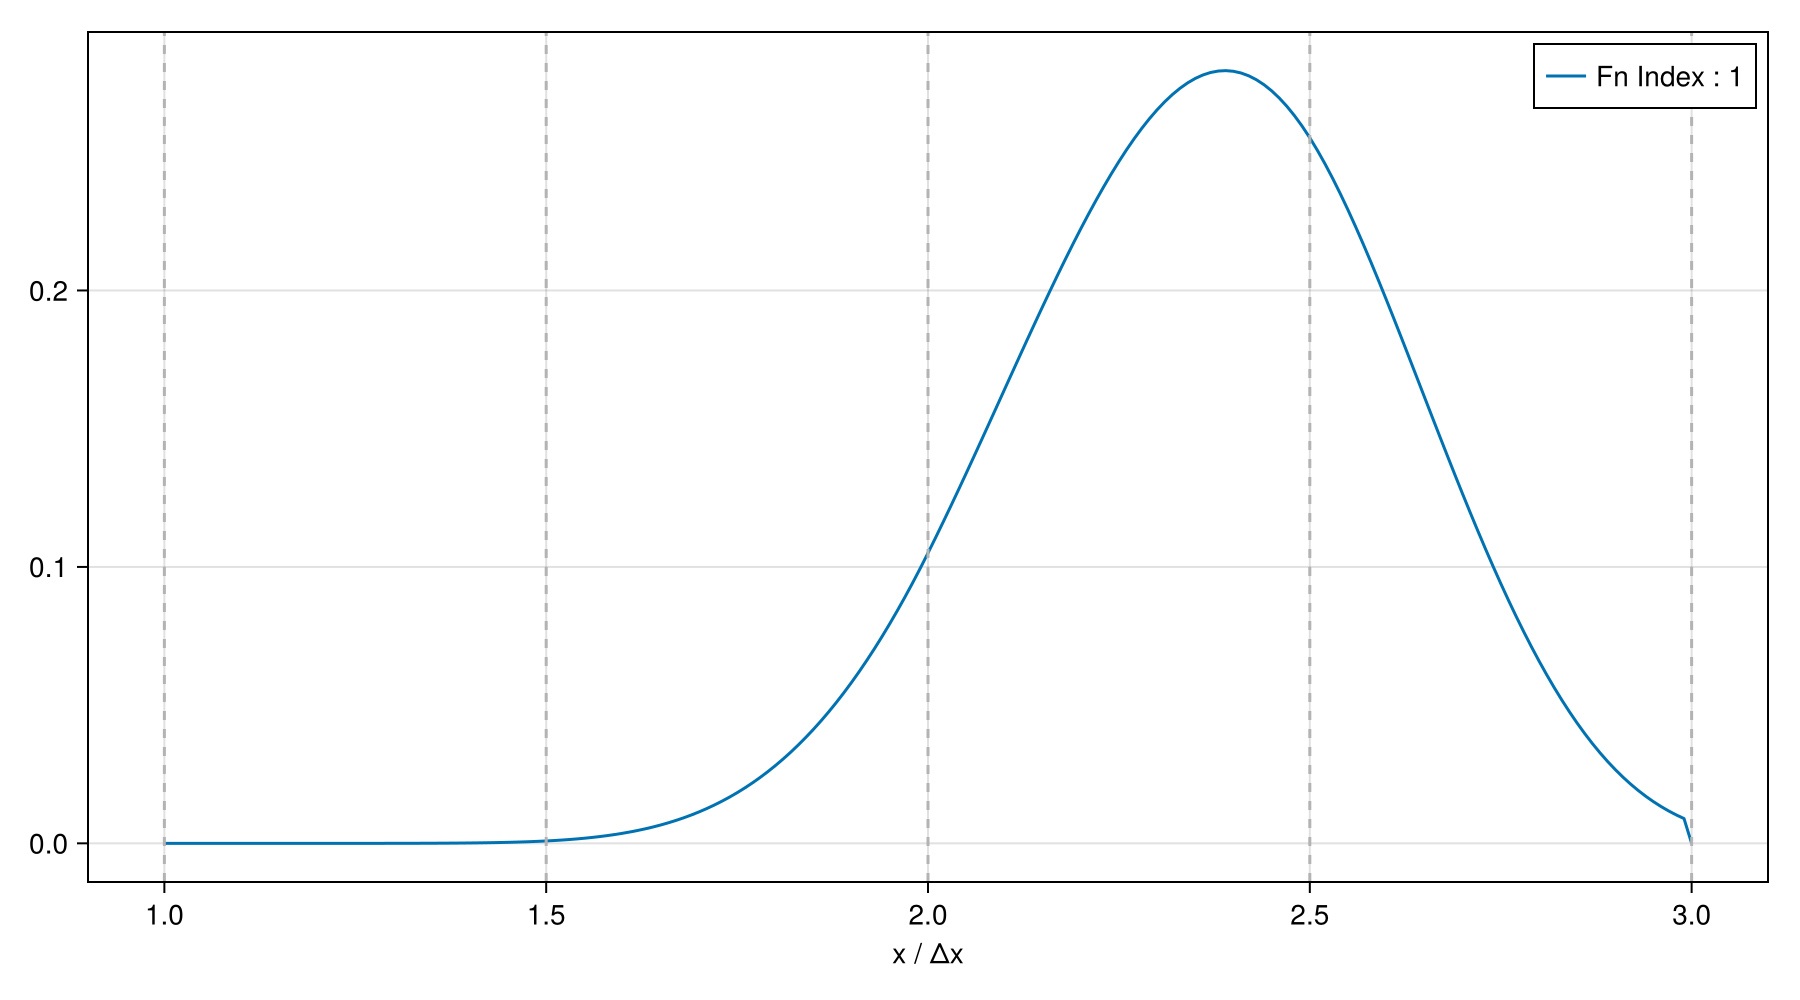

In [18]:
plotCompactSymbolicFunctions(WYYKK,(1,1,3,3,);N=50)

In [19]:
WYYKK.data[:,1,1,1,2,2]

5-element Vector{Num}:
         (0.0023046643406303136(x^8) - 0.021400454591567197(x^7)*Δx + 0.08474344848429934(x^6)*(Δx^2) - 0.18740683806615274(x^5)*(Δx^3) + 0.25396871901627033(x^4)*(Δx^4) - 0.21664138764213292(x^3)*(Δx^5) + 0.11391406126256434(x^2)*(Δx^6) - 0.03383946882291563x*(Δx^7) + 0.004357256019004187(Δx^8)) / (0.0008466113904356254(Δx^8))
   (2.201134492867316e13(x^8) - 3.301701739300974e14(x^7)*Δx + 2.107586276920455e15(x^6)*(Δx^2) - 7.45817737333209e15(x^5)*(Δx^3) + 1.5969689315438394e16(x^4)*(Δx^4) - 2.116711813672134e16(x^3)*(Δx^5) + 1.6970326584461492e16(x^2)*(Δx^6) - 7.537586357293519e15x*(Δx^7) + 1.4234385195280322e15(Δx^8)) / (4.402268985734632e13(Δx^8))
 (-5.0266389671545166e10(x^8) + 9.04795014087813e11(x^7)*Δx - 6.999594761762665e12(x^6)*(Δx^2) + 3.033995503258347e13(x^5)*(Δx^3) - 8.04209873922148e13(x^4)*(Δx^4) + 1.3317870500185595e14(x^3)*(Δx^5) - 1.3424957109154262e14(x^2)*(Δx^6) + 7.516910961995222e13x*(Δx^7) - 1.7878559234053168e13(Δx^8)) / (5.02663896715451

# making analytic integrals

In [20]:
WYYKK_integral=lazyProduceOrLoad("WYYKK_integral_tmp",integrate,WYYKK,x)


Computing WYYKK_integral_tmp


CompactSymbolicFunctions{4, Array{Num, 6}}(5, 1, (5, 5, 4, 4), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[(0.9517679214477539x) / 0.8009033203125 + (-16.945037841796875(x^6)) / (0.8009033203125(Δx^5)) + (0.12359619140625(x^9)) / (0.8009033203125(Δx^8)) + (27.054402923583986(x^5)) / (0.8009033203125(Δx^4)) + (15.976584434509277(x^3)) / (0.8009033203125(Δx^2)) + (-26.725281715393066(x^4)) / (0.8009033203125(Δx^3)) + (6.437419346400669(x^7)) / (0.8009033203125(Δx^6)) + (-1.3626480102539062(x^8)) / (0.8009033203125(Δx^7)) + (-5.42764949798584(x^2)) / (0.8009033203125Δx); (1.4193673615859985e7x) / 1.7025314458007812e6 + (-1.4187762048339844e6(x^6)) / (1.7025314458007812e6(Δx^5)) + (-1.894066233453369e7(x^4)) / (1.7025314458007812e6(Δx^3)) + (-2.8097680423233032e7(x^2)) / (1.7025314458007812e6Δx) + (3.0127318605148315e7(x^3)) / (1.7025314458007812e6(Δx^2)) + (7.008754451879883e6(x^5)) / (1.7025314458007812e6(Δx^4)) + (121609.38898577009(x^7)) / (1.7025314458007812e6(Δx^6)); … ; 0.0; 0.0;;

In [21]:
WYYKK_integral.data[:,1,1,1,2,2]

5-element Vector{Num}:
  (0.004357256019004187x) / 0.0008466113904356254 + (-0.031234473011025457(x^6)) / (0.0008466113904356254(Δx^5)) + (0.0002560738156255904(x^9)) / (0.0008466113904356254(Δx^8)) + (0.012106206926328475(x^7)) / (0.0008466113904356254(Δx^6)) + (-0.0026750568239458997(x^8)) / (0.0008466113904356254(Δx^7)) + (0.037971353754188114(x^3)) / (0.0008466113904356254(Δx^2)) + (-0.05416034691053323(x^4)) / (0.0008466113904356254(Δx^3)) + (-0.016919734411457815(x^2)) / (0.0008466113904356254Δx) + (0.05079374380325407(x^5)) / (0.0008466113904356254(Δx^4))
        (1.4234385195280322e15x) / 4.402268985734632e13 + (3.0108375384577925e14(x^7)) / (4.402268985734632e13(Δx^6)) + (-3.7687931786467595e15(x^2)) / (4.402268985734632e13Δx) + (-5.291779534180335e15(x^4)) / (4.402268985734632e13(Δx^3)) + (5.65677552815383e15(x^3)) / (4.402268985734632e13(Δx^2)) + (-4.127127174126217e13(x^8)) / (4.402268985734632e13(Δx^7)) + (2.4457049920747954e12(x^9)) / (4.402268985734632e13(Δx^8)) + (3.193

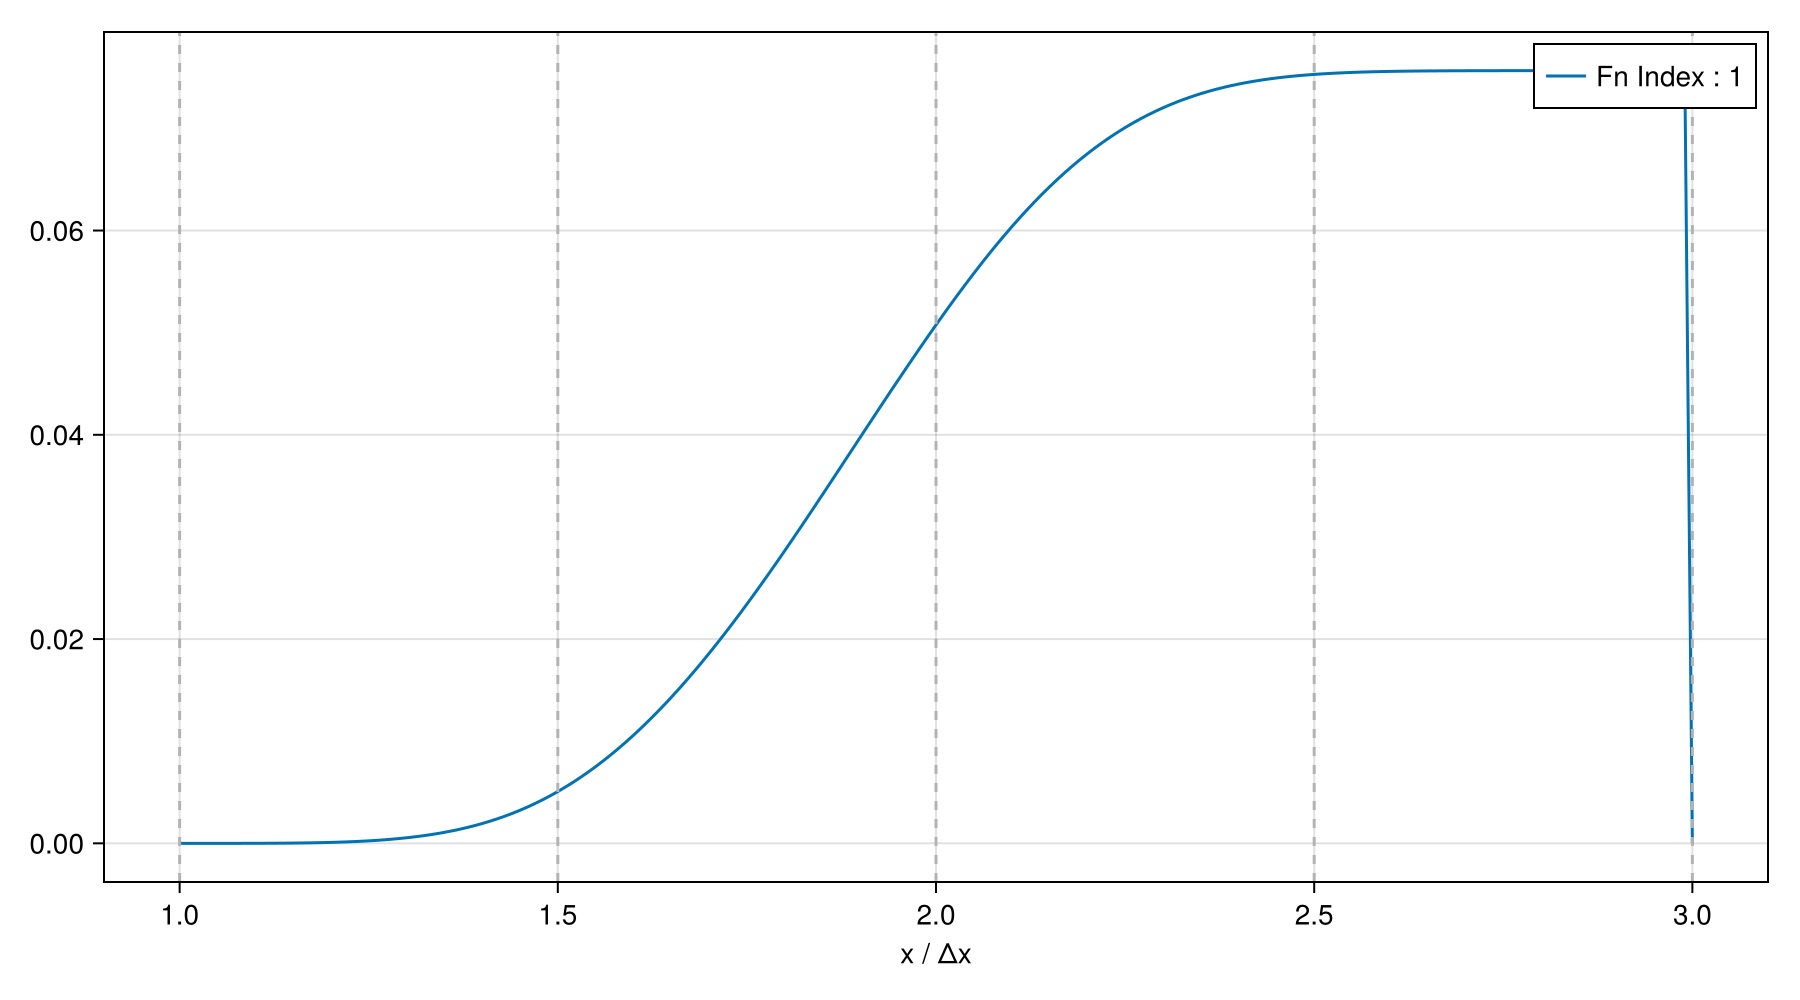

In [22]:
continuousAntiDerivativesMaker!(WYYKK_integral) # this is only to 'visually' make beautiful the anti-derivatives
plotCompactSymbolicFunctions(WYYKK_integral,(1,1,2,2,);N=50)

# double check that the anti-derivatives are ok


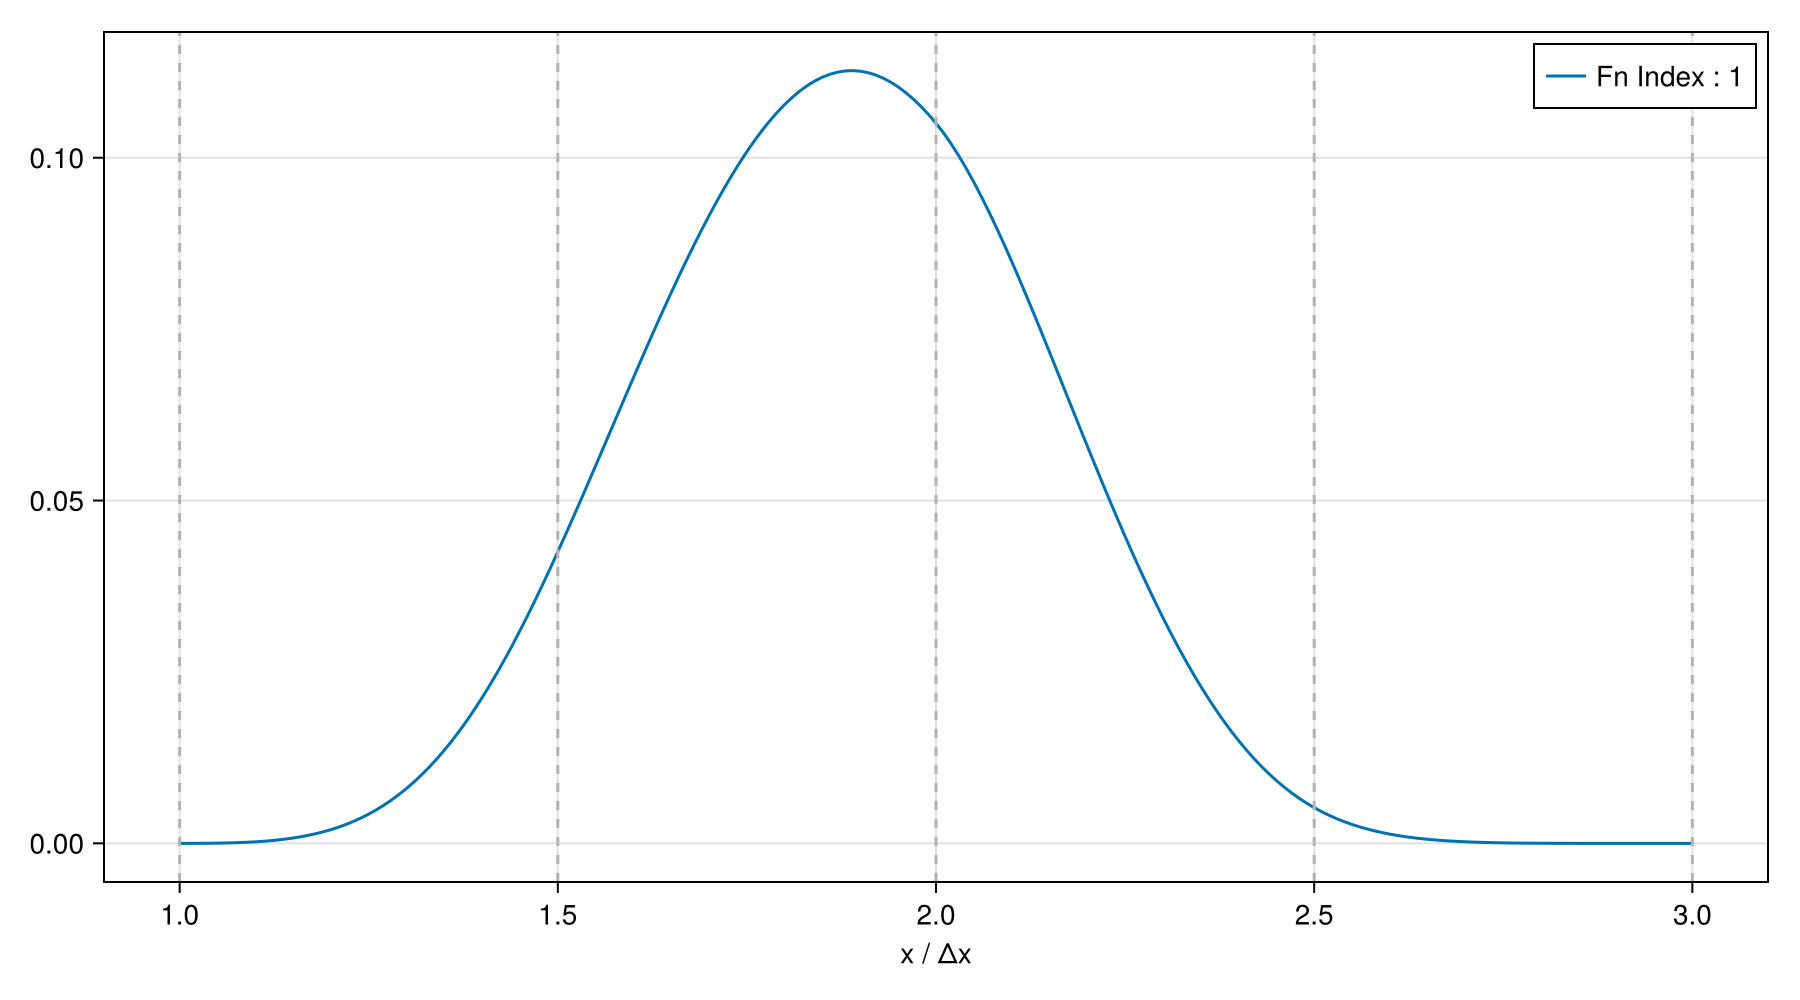

In [36]:
WYYKK_recovered=differentiate(WYYKK_integral,x)
plotCompactSymbolicFunctions(WYYKK_recovered,(1,1,2,2,);N=50)


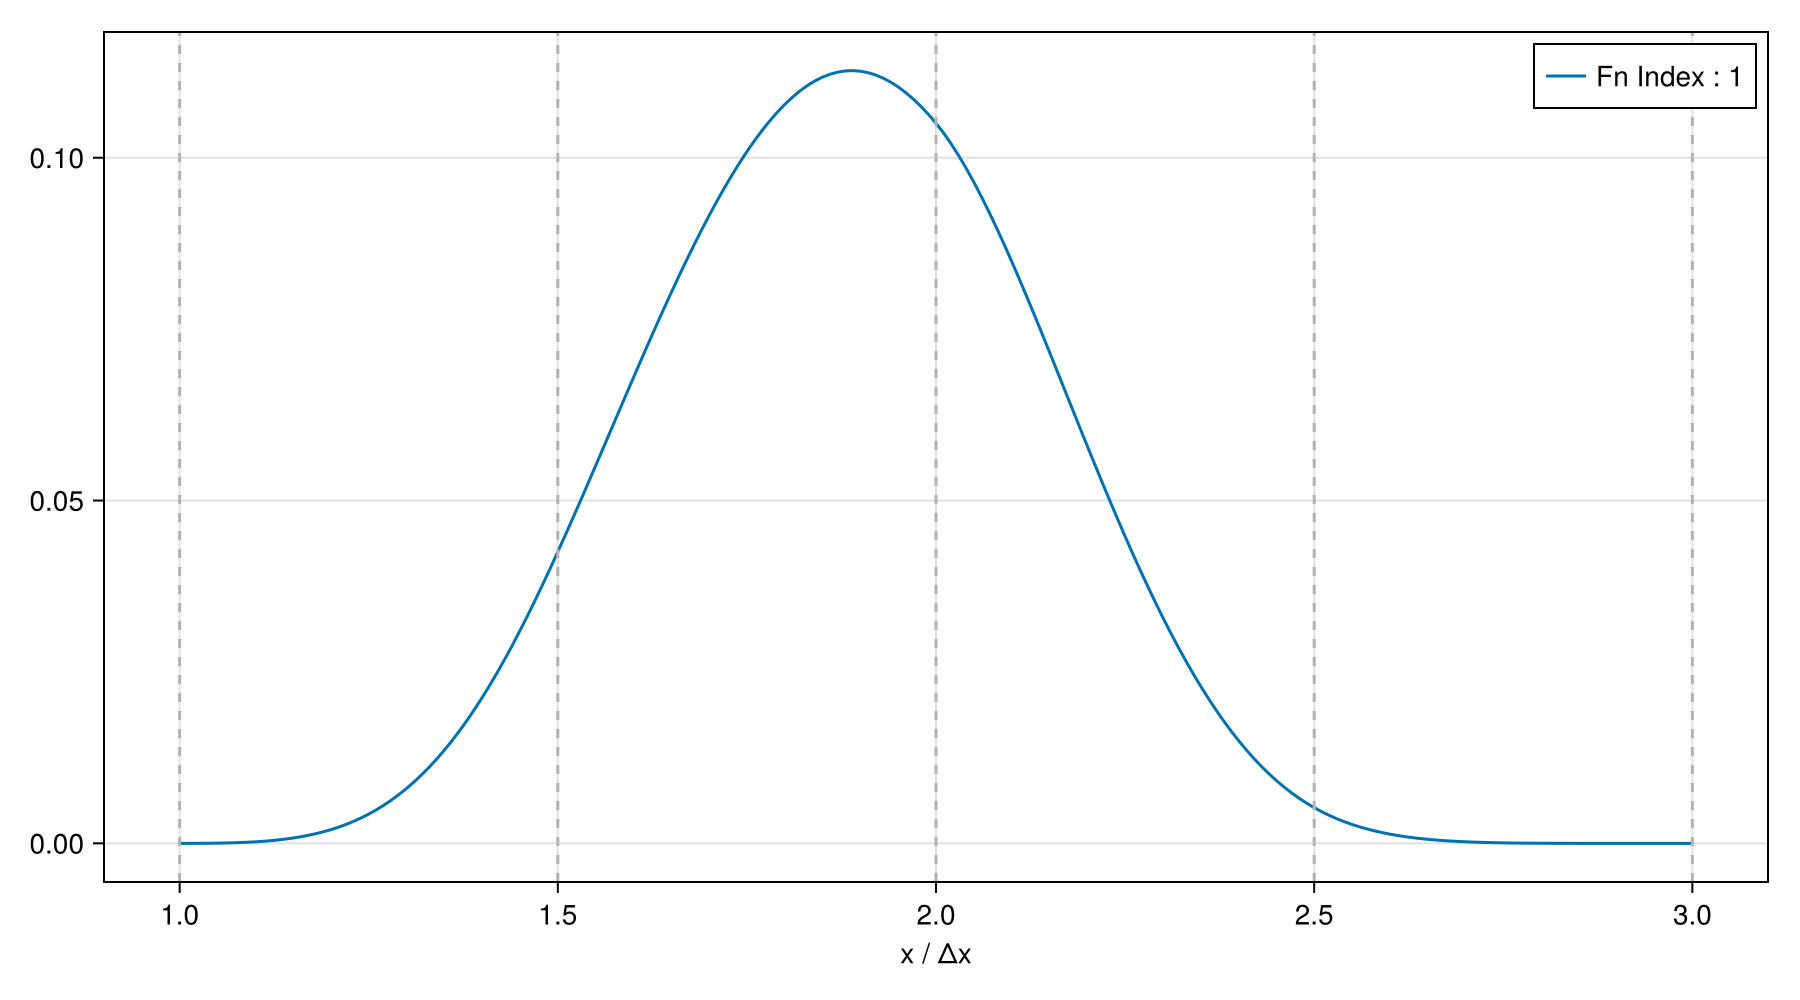

In [37]:
plotCompactSymbolicFunctions(WYYKK,(1,1,2,2,);N=50)

# now putting numerical Δx to have the WYYKK values 

In [38]:
coefWYYKK = Array{Float64, 4}(undef,l_n_max+1,lᶜ_nᶜ_max+1,length(μs),length(μᶜs))

nodes = WYYKK_integral.nodes
numericalNodes = Δ .* nodes
numNodes = WYYKK_integral.numberNodes
x = WYYKK_integral.variables[1]
Δx = WYYKK_integral.variables[2]
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    tmpAntiDerivative=WYYKK_integral.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ]
    tmpCoef = 0.0
    for ι in 1:numNodes-1
        xLeft = numericalNodes[ι]
        xRight = numericalNodes[ι+1]
        expr = tmpAntiDerivative[ι]
        rightValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xRight, Δx => Δ)))
        leftValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xLeft, Δx => Δ)))
        tmpCoef += rightValue-leftValue
    end
    coefWYYKK[l_n_slot,lᶜ_nᶜ_slot,iμ,iμᶜ] = tmpCoef
end

In [39]:
coefWYYKK

5×5×4×4 Array{Float64, 4}:
[:, :, 1, 1] =
 0.0203631   0.0204007   0.0124737   0.00549707   0.00187755
 0.0204007   0.0249473   0.0164912   0.00751018   0.00260666
 0.0124737   0.0164912   0.0112653   0.00521332   0.00182629
 0.00549707  0.00751018  0.00521332  0.00243505   0.000858297
 0.00187755  0.00260666  0.00182629  0.000858297  0.000303912

[:, :, 2, 1] =
 0.0281172    0.0251746    0.0130783    0.00497312   0.00150477
 0.011116     0.0135694    0.00838018   0.00353251   0.00114084
 0.00400569   0.00498783   0.00320373   0.00139855   0.000464538
 0.000994996  0.00130451   0.000864599  0.000386292  0.000130692
 0.000201753  0.000269236  0.000181644  8.24051e-5   2.82427e-5

[:, :, 3, 1] =
  0.0398444     0.0499512     0.0323849     0.0143115     0.00481786
 -0.00981549   -0.010157     -0.00564289   -0.00219577   -0.000663687
  0.00228313    0.00197484    0.00093851    0.000319453   8.61058e-5
 -0.000483283  -0.000361749  -0.000149802  -4.49188e-5   -1.08015e-5
  9.0794e-5     6.07